['Q15_D15.json', 'Q14_D15.json', 'Q12_D15.json', 'Q7_D15.json', 'Q13_D15.json', 'Q4_D15.json', 'Q17_D15.json', 'Q6_D15.json', 'Q9_D15.json', 'Q3_D15.json', 'Q5_D15.json', 'Q11_D15.json', 'Q10_D15.json', 'Q16_D15.json', 'Q8_D15.json', 'Q2_D15.json']


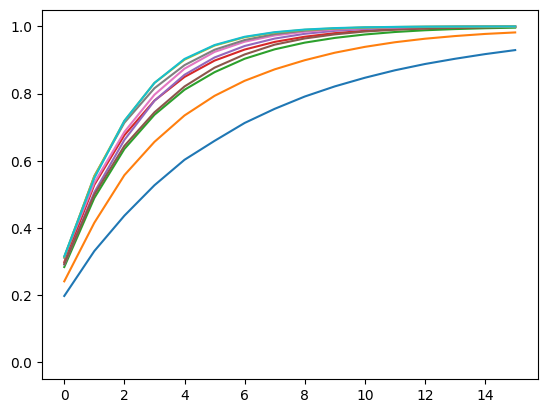

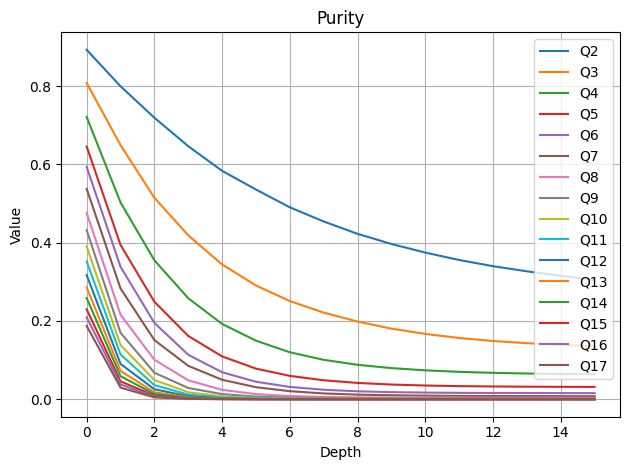

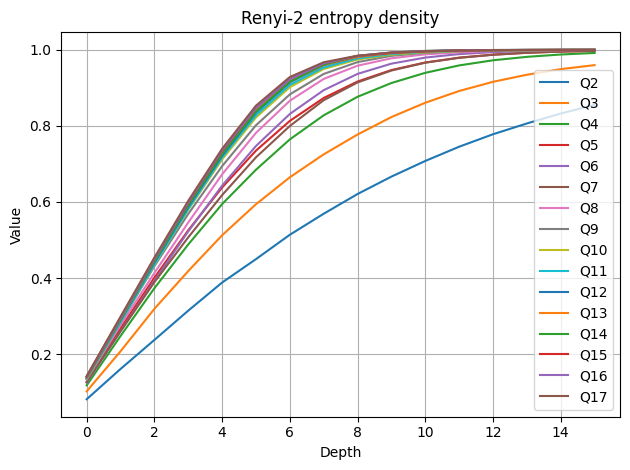

In [3]:
# ...existing code...

import re
import os
import json
import matplotlib.pyplot as plt

# Set directory with your JSON files
json_dir = "../"  # Change this to your actual path
json_files = [f for f in os.listdir(json_dir) if f.endswith(".json")]
print(json_files)

data_by_key = {}

for filename in json_files:
    path = os.path.join(json_dir, filename)
    with open(path, 'r') as file:
        try:
            content = json.load(file)
        except json.JSONDecodeError:
            print(f"Skipping invalid JSON file: {filename}")
            continue

        for key, lists in content.items():
            if not isinstance(lists, list):
                continue
            if key not in data_by_key:
                data_by_key[key] = {}
            data_by_key[key][filename] = lists


# Sort files by qubit number extracted from filename
def qubit_number(fname):
    match = re.search(r'Q(\d+)_', fname)
    return int(match.group(1)) if match else 0

for key, file_data in data_by_key.items():
    plt.figure()
    # Sort filenames by qubit number
    sorted_files = sorted(file_data.keys(), key=qubit_number)
    for fname in sorted_files:
        sequences = file_data[fname]
        # Extract QN from filename for legend
        match = re.search(r'(Q\d+)_', fname)
        qlabel = match.group(1) if match else fname
        for i, seq in enumerate(sequences):
            label = qlabel if len(sequences) == 1 else f"{qlabel} [{i}]"
            plt.plot(seq, label=label)
     
    if key == "all_pur_diff_n":
        title = "Purity"
        plt.title(title)
        plt.xlabel("Depth")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
    elif key == "all_R2d_diff_n":
        title = "Renyi-2 entropy density"
        plt.title(title)
        plt.xlabel("Depth")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

plt.show()

['Q15_D15.json', 'Q14_D15.json', 'Q12_D15.json', 'Q7_D15.json', 'Q13_D15.json', 'Q4_D15.json', 'Q17_D15.json', 'Q6_D15.json', 'Q9_D15.json', 'Q3_D15.json', 'Q5_D15.json', 'Q11_D15.json', 'Q10_D15.json', 'Q16_D15.json', 'Q8_D15.json', 'Q2_D15.json']


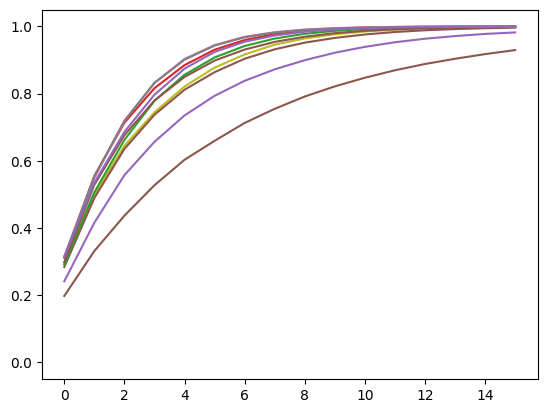

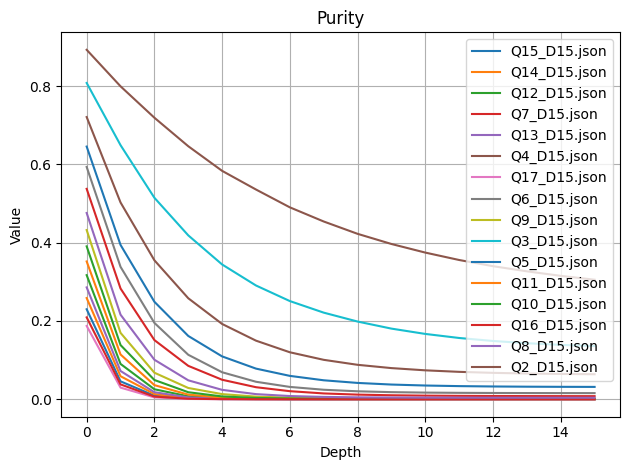

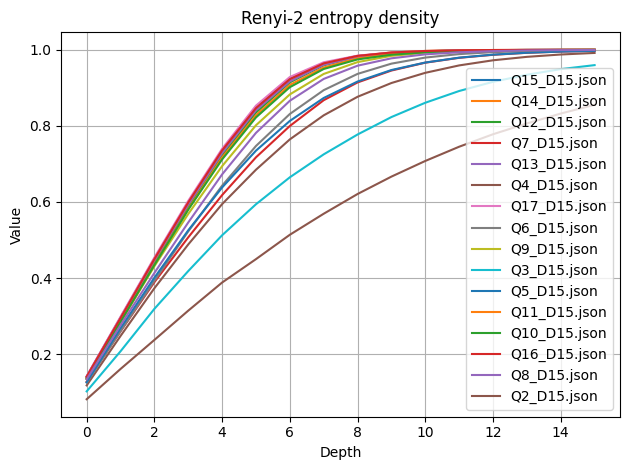

In [2]:
import os
import json
import matplotlib.pyplot as plt

# Set directory with your JSON files
json_dir = "../"  # Change this to your actual path
json_files = [f for f in os.listdir(json_dir) if f.endswith(".json")]
print(json_files)

data_by_key = {}

for filename in json_files:
    path = os.path.join(json_dir, filename)
    with open(path, 'r') as file:
        try:
            content = json.load(file)
        except json.JSONDecodeError:
            print(f"Skipping invalid JSON file: {filename}")
            continue

        for key, lists in content.items():
            if not isinstance(lists, list):
                continue
            if key not in data_by_key:
                data_by_key[key] = {}
            data_by_key[key][filename] = lists

# Plot one graph per list name
for key, file_data in data_by_key.items():
    plt.figure()
    #print(file_data)
    for fname, sequences in file_data.items():
        for i, seq in enumerate(sequences):
            label = f"{fname} [{i}]" if len(sequences) > 1 else fname
           # print(label)
            plt.plot(seq, label=label)
     
    if key == "all_pur_diff_n":
        title = "Purity"
        plt.title(title)
        plt.xlabel("Depth")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
    elif key == "all_R2d_diff_n":
        title = "Renyi-2 entropy density"
        plt.title(title)
        plt.xlabel("Depth")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

plt.show()
